In [4]:
import librosa
from scipy.signal import butter, filtfilt
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd


In [14]:
dataset = '../EMOVO/'
#actors = ['f1','f2','f3','m1','m2','m3']
actors = ['f1']
files = []

for path in actors:
    actors_paths = dataset + path +'/'
    for file in os.listdir(actors_paths):
        if file.endswith(".wav"):
            files.append(actors_paths + file)

print(len(files))

1


we define a function to resample the audioFiles

In [15]:
def resample_audio(audio_path, ismono = True,  target_sr=22050):
    y, sr = librosa.load(audio_path, mono=ismono, sr=None)
    return y, sr

resample_audio(files[0])


(array([-3.8146973e-04, -5.0354004e-04, -1.8310547e-04, ...,
         1.5258789e-04,  1.5258789e-05,  1.2207031e-04], dtype=float32),
 48000)

In [16]:
resampled_files = []
for file in files:
    resampled_files.append(resample_audio(file)[0])

print(len(resampled_files))
resampled_files[0]



1


array([-3.8146973e-04, -5.0354004e-04, -1.8310547e-04, ...,
        1.5258789e-04,  1.5258789e-05,  1.2207031e-04], dtype=float32)

now we define a function to reduce noise

In [17]:

from scipy.signal import butter, sosfilt, sosfreqz
def butter_bandpass(signal, fs, lowcut=100, highcut=8000, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')

    return sosfilt(sos, signal)

In [18]:
def plot_frequency(y, sr):
    n = len(y)
    f = np.fft.fftfreq(n, 1/sr)
    Y = np.fft.fft(y)
    plt.plot(f, np.abs(Y))
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude')
    plt.show()


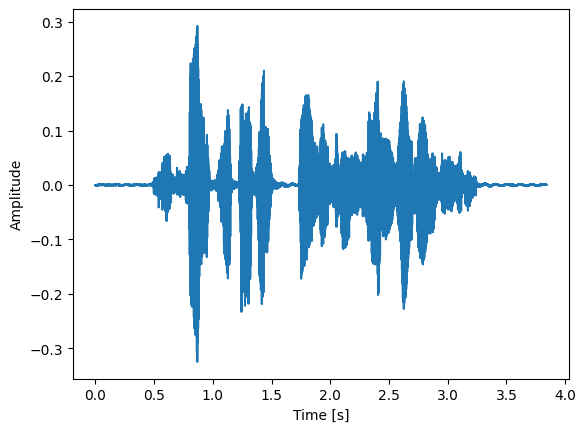

(184320,) (184320,)


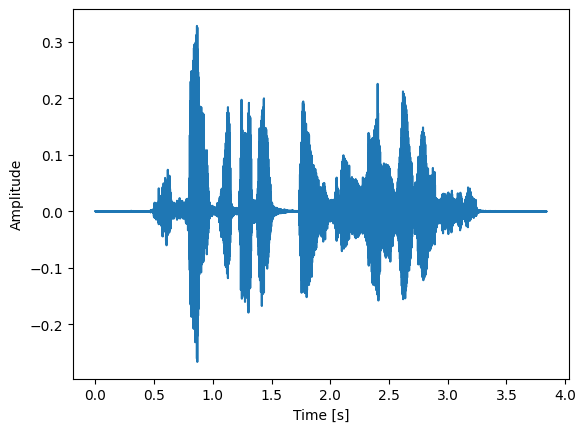

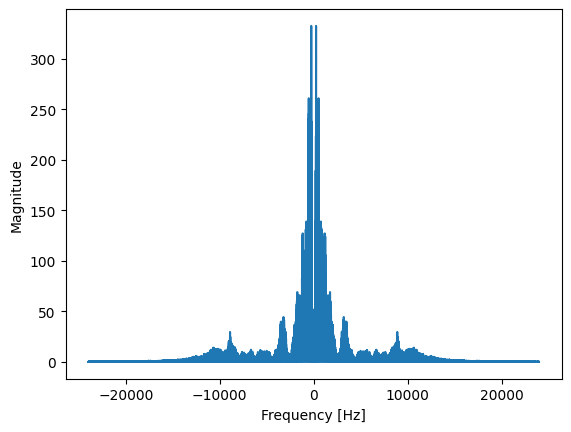

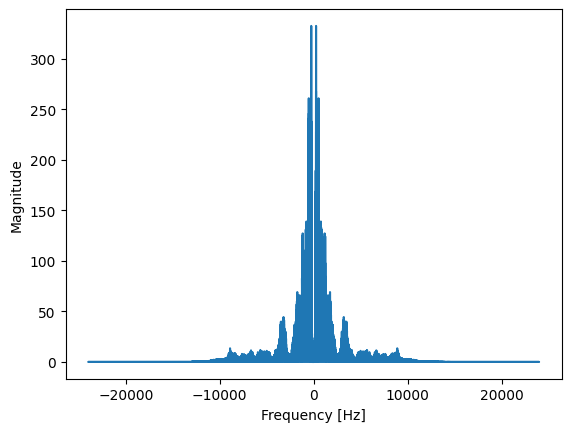

In [19]:
# lets try the function on one audio
fs = 48000
y = resampled_files[0]
t = np.linspace(0, len(y)/fs, len(y))
plt.plot(t, y)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
y_butter_filter = butter_bandpass(y, fs, lowcut=100, highcut=8000, order=5)
print(y_butter_filter.shape, y.shape)
plt.plot(t, y_butter_filter)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
plot_frequency(y, fs)
plot_frequency(y_butter_filter, fs)


import sounddevice as sd
sd.play(y, fs)
sd.wait()
sd.play(y_butter_filter, fs)


In [20]:
#now let's design a function that apply chebyshev filter in order to remove the noise
from scipy.signal import cheby1, sosfilt

def apply_chebyshev_filter(signal, fs, lowcut=100, highcut=8000, order=5, rp=5):
    low = lowcut / (0.5 * fs)
    high = highcut / (0.5 * fs)
    
    # Applica il filtro di Chebyshev
    sos = cheby1(order, rp, [low, high], btype='band', output='sos')
    filtered_signal = sosfilt(sos, signal)
    
    return filtered_signal



(184320,) (184320,)


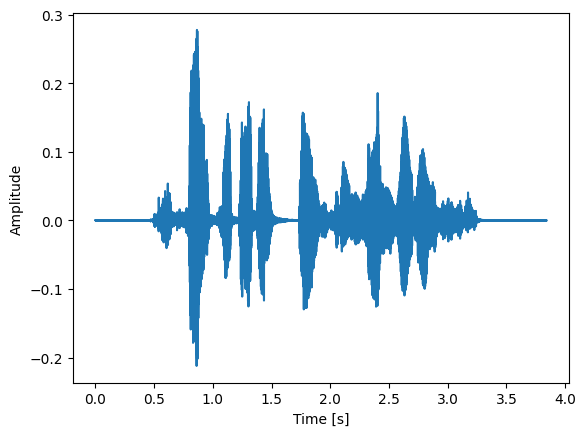

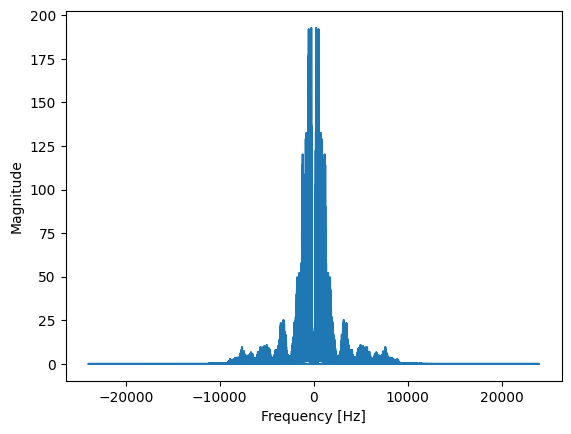

In [21]:
y_butter_chebyshev_filter = apply_chebyshev_filter(y, fs)
print(y_butter_chebyshev_filter.shape, y_butter_filter.shape)
plt.plot(t, y_butter_chebyshev_filter)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()
plot_frequency(y_butter_chebyshev_filter, fs)

sd.play(y_butter_filter, fs)
sd.wait()
sd.play(y_butter_chebyshev_filter, fs)



In [22]:
def extract_pitch(y, sr):
    pitches, magnitudes = librosa.core.piptrack(y=y, sr=sr)
    pitch = []
    for i in range(0, len(pitches)):
        pitch.append(pitches[i][np.argmax(magnitudes[i])])
    return pitch

#we extract the pitch
pitch_y = extract_pitch(y, fs)
pitch_y_butter = extract_pitch(y_butter_filter, fs)

